In [35]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from typing import Optional, Tuple

In [36]:
DATA_DIR = Path("./data")

In [37]:
def find_newest_log_files(data_dir: Path) -> Tuple[Optional[Path], Optional[Path], Optional[str]]:
    """
    Finds the newest pair of event/object CSV files in a directory based
    on the timestamp in the filename.
    
    Filename format: YYYY-MM-DD_HH-MM-SS_ocel_name_(event|object).csv
    """
    
    # Regex to capture: 1:timestamp, 2:ocel_name, 3:type
    pattern = re.compile(r"(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})_([^_]+)_(event|object)\.csv")
    
    parsed_files = []
    for csv_file in data_dir.glob("*.csv"):
        match = pattern.match(csv_file.name)
        if match:
            timestamp, ocel_name, file_type = match.groups()
            parsed_files.append((timestamp, ocel_name, file_type, csv_file))
            
    if not parsed_files:
        print(f"Error: No matching log files found in {data_dir.resolve()}")
        return None, None, None
        
    # Find the latest timestamp (string comparison works for this format)
    latest_timestamp = max(item[0] for item in parsed_files)
    
    # Find the matching files for this exact timestamp
    event_file_info = next((item for item in parsed_files if item[0] == latest_timestamp and item[2] == 'event'), None)
    object_file_info = next((item for item in parsed_files if item[0] == latest_timestamp and item[2] == 'object'), None)
    
    if not event_file_info or not object_file_info:
        print(f"Error: Found timestamp {latest_timestamp}, but could not find a matching event/object file pair.")
        return None, None, None
        
    ocel_name = event_file_info[1]
    event_file_path = event_file_info[3]
    object_file_path = object_file_info[3]
    
    print(f"\nFound newest files for OCEL: '{ocel_name}' (Timestamp: {latest_timestamp})")
    print(f"Event file:   {event_file_path.name}")
    print(f"Object file:  {object_file_path.name}")
    
    return event_file_path, object_file_path, ocel_name

In [38]:
def remove_outliers(df: pd.DataFrame, column: str, n_std: float = 3.0) -> pd.DataFrame:
    """
    Removes outliers from a DataFrame based on the Z-score of a specific column.
    
    A Z-score measures how many standard deviations a data point is from the mean.
    
    Parameters:
    -----------
    df : pd.DataFrame
        The input DataFrame.
    column : str
        The name of the column to check for outliers (e.g., 'time').
    n_std : float
        The number of standard deviations to use as the threshold.
        Any row with a Z-score *absolute value* greater than this will be removed.
        A common value is 3.0.
        
    Returns:
    --------
    pd.DataFrame
        A new DataFrame with the outliers removed.
    """
    if df.empty or column not in df.columns:
        return df 
    
    # Calculate the mean and standard deviation
    col_mean = df[column].mean()
    col_std = df[column].std()

    # Avoid division by zero if standard deviation is 0
    if col_std == 0:
        return df
        
    # Calculate the Z-score for each data point in the column
    z_scores = (df[column] - col_mean) / col_std
    
    # Create a boolean mask for all rows where the Z-score is within the threshold
    is_not_outlier = z_scores.abs() <= n_std
    
    # Return the filtered DataFrame
    return df[is_not_outlier]

In [39]:
def plot_timing_chart(ax: plt.Axes, df: pd.DataFrame, x_col: str, y_col: str, x_label: str):
    """
    Plots a transparent scatter plot on the given Matplotlib axes.
    """
    # Check if data exists
    if df.empty or x_col not in df.columns or y_col not in df.columns:
        ax.text(0.5, 0.5, f"Data missing or columns invalid:\n({x_col}, {y_col})", 
                ha='center', va='center', style='italic', color='red')
        return

    # 'o' specifies a dot. 'alpha' controls transparency. 'markersize' controls dot size.
    ax.plot(df[x_col], df[y_col], 'o', alpha=0.4, markersize=5, label=f"{x_col}_vs_{y_col}")
    
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel("Time (s)", fontsize=12)
    
    # Light gruid
    ax.grid(True, linestyle='--', alpha=0.6)

In [40]:
def create_comparison_plots(event_df: pd.DataFrame, 
                            object_df: pd.DataFrame, 
                            ocel_name: str, 
                            plot_title_suffix: str = ""):
    """
    Generates the side-by-side Event vs. Time and Object vs. Time scatter plots.
    """
    # Create a figure with two subplots, side-by-side (1 row, 2 columns)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Add a main title for the whole figure
    fig.suptitle(f"Timing Analysis for OCEL: {ocel_name}{plot_title_suffix}", fontsize=16)
    
    # Call the plotting function for the first plot (Events)
    plot_timing_chart(ax=ax1, 
                      df=event_df, 
                      x_col='no_events', 
                      y_col='time', 
                      x_label='Number of Events')
    
    # Call the plotting function for the second plot (Objects)
    plot_timing_chart(ax=ax2, 
                      df=object_df, 
                      x_col='no_objects', 
                      y_col='time', 
                      x_label='Number of Objects')
    
    # Adjust layout to prevent labels from overlapping
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 'rect' makes room for suptitle
    
    # Display the plots in the notebook output
    plt.show()


Found newest files for OCEL: 'ocel2-p2p.json' (Timestamp: 2025-11-13_17-34-31)
Event file:   2025-11-13_17-34-31_ocel2-p2p.json_event.csv
Object file:  2025-11-13_17-34-31_ocel2-p2p.json_object.csv

Successfully loaded 927 event data points.
Successfully loaded 927 object data points.


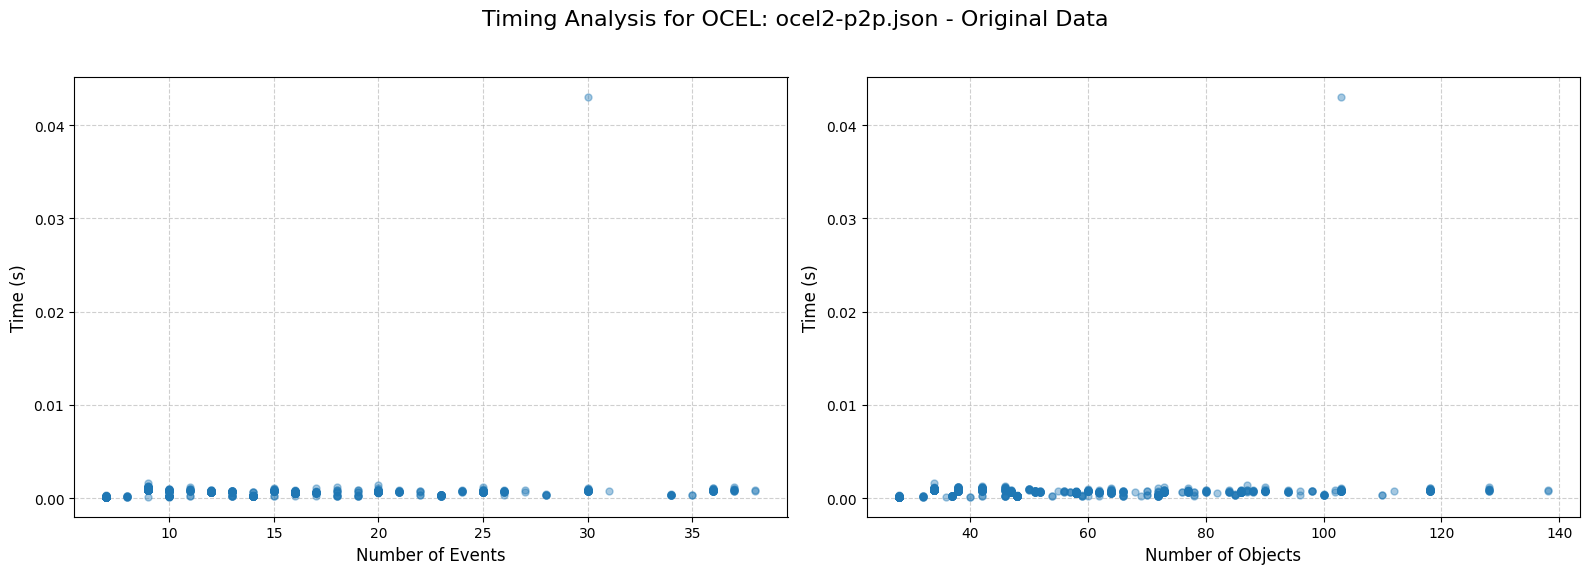


--- Removing Outliers (Threshold: 3.0 std dev on 'time') ---
Removed 1 outliers from event data.
Removed 1 outliers from object data.


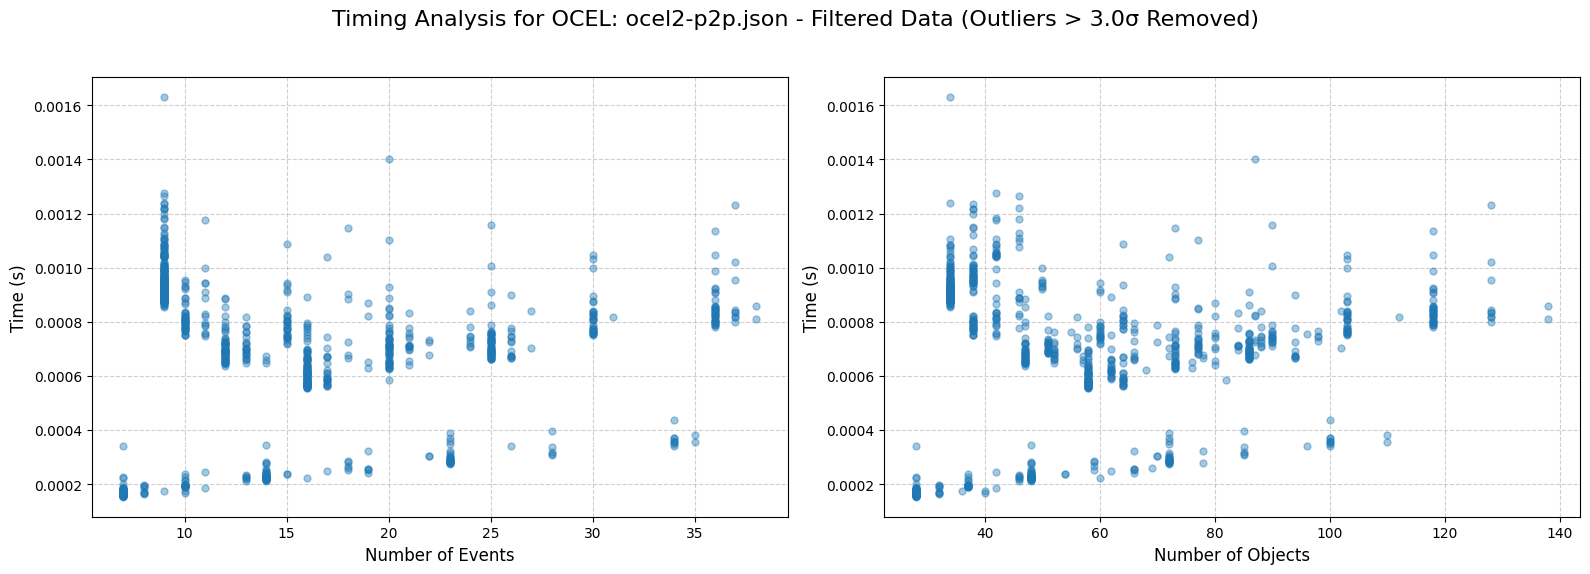

In [41]:
# Threshold for outlier removal (default: 3.0 standard deviations)
OUTLIER_THRESHOLD_STD = 3.0

# --- Find and Load Data ---
event_file, object_file, ocel_name = find_newest_log_files(DATA_DIR)

if event_file and object_file:
    try:
        event_df = pd.read_csv(event_file)
        object_df = pd.read_csv(object_file)
        
        print(f"\nSuccessfully loaded {len(event_df)} event data points.")
        print(f"Successfully loaded {len(object_df)} object data points.")

        # --- Plot Original Data ---
        create_comparison_plots(event_df, 
                                object_df, 
                                ocel_name, 
                                plot_title_suffix=" - Original Data")

        # --- Remove Outliers ---
        print(f"\n--- Removing Outliers (Threshold: {OUTLIER_THRESHOLD_STD} std dev on 'time') ---")
        
        event_df_filtered = remove_outliers(event_df, 'time', n_std=OUTLIER_THRESHOLD_STD)
        object_df_filtered = remove_outliers(object_df, 'time', n_std=OUTLIER_THRESHOLD_STD)
        
        event_rows_removed = len(event_df) - len(event_df_filtered)
        object_rows_removed = len(object_df) - len(object_df_filtered)
        
        print(f"Removed {event_rows_removed} outliers from event data.")
        print(f"Removed {object_rows_removed} outliers from object data.")

        # --- Plot Filtered Data ---
        create_comparison_plots(event_df_filtered, 
                                object_df_filtered, 
                                ocel_name, 
                                plot_title_suffix=f" - Filtered Data (Outliers > {OUTLIER_THRESHOLD_STD}σ Removed)")
        
    except Exception as e:
        print(f"An error occurred while loading or plotting data: {e}")
else:
    print("\nAborting: Could not find the necessary event and object files.")